<a href="https://colab.research.google.com/github/NguyenAnhDo165/CNN-Exercise/blob/main/Nh%E1%BA%ADn%20di%E1%BB%87n%20%C4%91%E1%BB%93%20%C4%83n%20Vi%E1%BB%87t%20Nam.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import kagglehub
import os
import tensorflow as tf

# Tải dataset Vietnamese Foods
path = kagglehub.dataset_download("quandang/vietnamese-foods")
print("Path to dataset files:", path)

base_dir = os.path.join(path, "Images")
train_dir = os.path.join(base_dir, "Train")
val_dir = os.path.join(base_dir, "Validate")
test_dir = os.path.join(base_dir, "Test")

print("Base:", base_dir)
print("Train:", train_dir)
print("Validate:", val_dir)
print("Test:", test_dir)
print("Folders:", os.listdir(base_dir))


100%|██████████| 4.17G/4.17G [00:33<00:00, 132MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/quandang/vietnamese-foods/versions/11
Base: /root/.cache/kagglehub/datasets/quandang/vietnamese-foods/versions/11/Images
Train: /root/.cache/kagglehub/datasets/quandang/vietnamese-foods/versions/11/Images/Train
Validate: /root/.cache/kagglehub/datasets/quandang/vietnamese-foods/versions/11/Images/Validate
Test: /root/.cache/kagglehub/datasets/quandang/vietnamese-foods/versions/11/Images/Test
Folders: ['Test', 'Train', 'Validate']


In [ ]:
# Kiểm tra số lượng class và số ảnh trong từng tập
for split_name, split_dir in [("Train", train_dir), ("Validate", val_dir), ("Test", test_dir)]:
    class_folders = sorted([
        d for d in os.listdir(split_dir)
        if os.path.isdir(os.path.join(split_dir, d))
    ])
    total_images = 0

    for class_name in class_folders:
        class_path = os.path.join(split_dir, class_name)
        total_images += len([
            f for f in os.listdir(class_path)
            if os.path.isfile(os.path.join(class_path, f))
        ])

    print(split_name, ":", len(class_folders), "classes -", total_images, "files")


Train : 30 classes - 17581 files
Validate : 30 classes - 2515 files
Test : 30 classes - 5040 files


In [ ]:
# Xóa file không phải ảnh phổ biến
# Lưu ý: lỗi của bạn không nằm ở extension, vì file hỏng có thể vẫn đuôi .jpg/.png
allowed_ext = (".jpg", ".jpeg", ".png", ".bmp", ".gif")
removed_files = []

for folder in [train_dir, val_dir, test_dir]:
    for root, dirs, files in os.walk(folder):
        for file in files:
            file_path = os.path.join(root, file)
            if not file.lower().endswith(allowed_ext):
                removed_files.append(file_path)
                os.remove(file_path)

print("Số file không đúng định dạng ảnh đã xóa:", len(removed_files))


Số file không đúng định dạng ảnh đã xóa: 0


In [ ]:
# Dò ảnh hỏng bằng chính TensorFlow
# Cell này xử lý lỗi: InvalidArgumentError tại decode_image/DecodeImage
bad_files = []

for folder in [train_dir, val_dir, test_dir]:
    for root, dirs, files in os.walk(folder):
        for file in files:
            file_path = os.path.join(root, file)

            try:
                img_bytes = tf.io.read_file(file_path)
                img = tf.io.decode_image(
                    img_bytes,
                    channels=3,
                    expand_animations=False
                )

                # Ép TensorFlow đọc thật sự để bắt lỗi ảnh hỏng
                _ = tf.shape(img).numpy()

                # Kiểm tra ảnh rỗng hoặc sai số chiều
                if img.shape.rank != 3:
                    bad_files.append(file_path)

            except Exception as e:
                bad_files.append(file_path)
                print("Ảnh lỗi:", file_path)
                print("Lỗi:", e)
                print("-" * 60)

print("Tổng số ảnh lỗi:", len(bad_files))


Ảnh lỗi: /root/.cache/kagglehub/datasets/quandang/vietnamese-foods/versions/11/Images/Train/Banh beo/356.jpg
Lỗi: {{function_node __wrapped__DecodeImage_device_/job:localhost/replica:0/task:0/device:CPU:0}} Input size should match (header_size + row_size * abs_height) but they differ by 2 [Op:DecodeImage] name: 
------------------------------------------------------------
Tổng số ảnh lỗi: 1


In [ ]:
# Xóa ảnh hỏng
for file_path in bad_files:
    if os.path.exists(file_path):
        os.remove(file_path)

print("Đã xóa", len(bad_files), "ảnh lỗi.")


Đã xóa 1 ảnh lỗi.


In [ ]:
# Tạo dataset sau khi đã xóa ảnh lỗi
IMG_HEIGHT = 180
IMG_WIDTH = 180
BATCH_SIZE = 32

train_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    label_mode="int",
    shuffle=True
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    val_dir,
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    label_mode="int",
    shuffle=False
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    test_dir,
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    label_mode="int",
    shuffle=False
)

class_names = train_ds.class_names
num_classes = len(class_names)

print("Số class:", num_classes)
print("Tên các class:", class_names)


Found 17580 files belonging to 30 classes.
Found 2515 files belonging to 30 classes.
Found 5040 files belonging to 30 classes.
Số class: 30
Tên các class: ['Banh beo', 'Banh bot loc', 'Banh can', 'Banh canh', 'Banh chung', 'Banh cuon', 'Banh duc', 'Banh gio', 'Banh khot', 'Banh mi', 'Banh pia', 'Banh tet', 'Banh trang nuong', 'Banh xeo', 'Bun bo Hue', 'Bun dau mam tom', 'Bun mam', 'Bun rieu', 'Bun thit nuong', 'Ca kho to', 'Canh chua', 'Cao lau', 'Chao long', 'Com tam', 'Goi cuon', 'Hu tieu', 'Mi quang', 'Nem chua', 'Pho', 'Xoi xeo']


In [ ]:
# Tối ưu tốc độ đọc dữ liệu
# Không dùng cache() vì dataset khá lớn, dễ tốn RAM và nếu ảnh lỗi còn sót thì cache làm debug khó hơn
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.prefetch(buffer_size=AUTOTUNE)
test_ds = test_ds.prefetch(buffer_size=AUTOTUNE)


In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Rescaling, Conv2D, MaxPooling2D, Flatten, Dense, Dropout

model = Sequential([
    Input(shape=(IMG_HEIGHT, IMG_WIDTH, 3)),

    Rescaling(1./255),

    Conv2D(32, (3, 3), activation="relu"),
    MaxPooling2D(2, 2),

    Conv2D(64, (3, 3), activation="relu"),
    MaxPooling2D(2, 2),

    Conv2D(128, (3, 3), activation="relu"),
    MaxPooling2D(2, 2),

    Flatten(),

    Dense(128, activation="relu"),
    Dropout(0.5),

    Dense(num_classes, activation="softmax")
])

model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 180, 180, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 178, 178, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 89, 89, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 87, 87, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 43, 43, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 41, 41, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 20, 20, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 51200)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     6,553,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 30)             │         3,870 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,650,846 (25.37 MB)

 Trainable params: 6,650,846 (25.37 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Adam thường ổn định hơn để bắt đầu train CNN cơ bản
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)


In [ ]:
EPOCHS = 10

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS
)


Epoch 1/10
550/550 ━━━━━━━━━━━━━━━━━━━━ 163s 280ms/step - accuracy: 0.0663 - loss: 3.3394 - val_accuracy: 0.1177 - val_loss: 3.1671
Epoch 2/10
550/550 ━━━━━━━━━━━━━━━━━━━━ 186s 264ms/step - accuracy: 0.1249 - loss: 3.1262 - val_accuracy: 0.1777 - val_loss: 2.9267
Epoch 3/10
550/550 ━━━━━━━━━━━━━━━━━━━━ 200s 262ms/step - accuracy: 0.1839 - loss: 2.8979 - val_accuracy: 0.2195 - val_loss: 2.7650
Epoch 4/10
550/550 ━━━━━━━━━━━━━━━━━━━━ 146s 265ms/step - accuracy: 0.2282 - loss: 2.6796 - val_accuracy: 0.2382 - val_loss: 2.6450
Epoch 5/10
550/550 ━━━━━━━━━━━━━━━━━━━━ 148s 270ms/step - accuracy: 0.2795 - loss: 2.4394 - val_accuracy: 0.2592 - val_loss: 2.5954
Epoch 6/10
550/550 ━━━━━━━━━━━━━━━━━━━━ 148s 268ms/step - accuracy: 0.3358 - loss: 2.2186 - val_accuracy: 0.2652 - val_loss: 2.5958
Epoch 7/10
550/550 ━━━━━━━━━━━━━━━━━━━━ 202s 269ms/step - accuracy: 0.3936 - loss: 1.9912 - val_accuracy: 0.2612 - val_loss: 2.6505
Epoch 8/10
550/550 ━━━━━━━━━━━━━━━━━━━━ 145s 264ms/step - accuracy: 0.4464 -

In [ ]:
# Đánh giá trên tập test
test_loss, test_acc = model.evaluate(test_ds)
print("Test loss:", test_loss)
print("Test accuracy:", test_acc)


 17/158 ━━━━━━━━━━━━━━━━━━━━ 28s 200ms/step - accuracy: 0.2310 - loss: 3.2853

In [ ]:
# Vẽ biểu đồ Accuracy và Loss
import matplotlib.pyplot as plt

plt.figure()
plt.plot(history.history["accuracy"], label="Train Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

plt.figure()
plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()


In [ ]:
from tensorflow.keras.models import load_model

# Load the saved model
loaded_model = load_model('/content/VietnameseFood.h5')

# Print a summary of the loaded model to verify
loaded_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 180, 180, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 178, 178, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 89, 89, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 87, 87, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 43, 43, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 41, 41, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 20, 20, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 51200)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     6,553,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 30)             │         3,870 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,650,848 (25.37 MB)

 Trainable params: 6,650,846 (25.37 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2 (12.00 B)

Found 5040 files belonging to 30 classes.


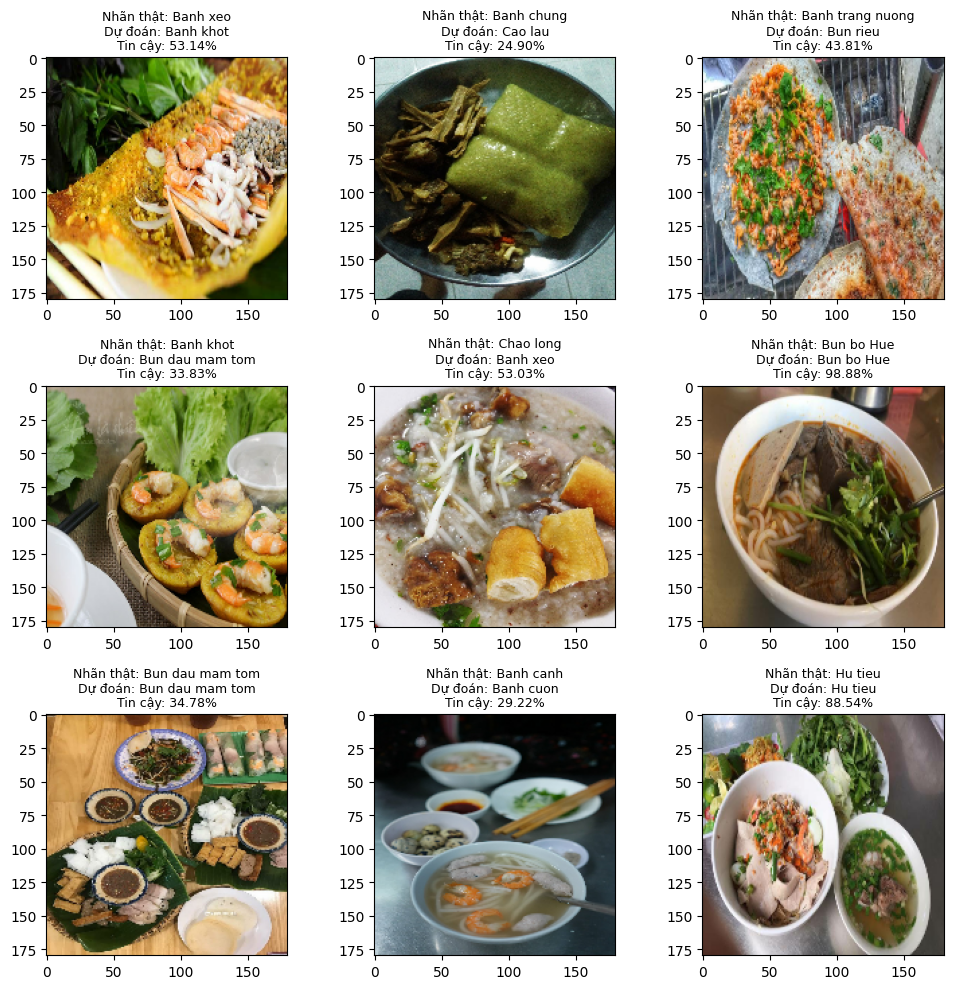

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

test_ds = tf.keras.utils.image_dataset_from_directory(
    test_dir,
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    label_mode="int",
    shuffle=True
)

for images, labels in test_ds.take(1):
    images = images.numpy()
    labels = labels.numpy()

indices = np.random.choice(len(images), 9, replace=False)

plt.figure(figsize=(10, 10))

for i, index in enumerate(indices):
    img = images[index]
    true_label_index = labels[index]
    true_label = class_names[true_label_index]

    prediction = loaded_model.predict(
        np.expand_dims(img, axis=0),
        verbose=0
    )

    predicted_label_index = np.argmax(prediction)
    predicted_label = class_names[predicted_label_index]
    confidence = np.max(prediction) * 100

    plt.subplot(3, 3, i + 1)
    plt.imshow(img.astype("uint8"))

    plt.title(
        f"Nhãn thật: {true_label}\nDự đoán: {predicted_label}\nTin cậy: {confidence:.2f}%",
        fontsize=9
    )

plt.tight_layout()
plt.show()